def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")# Multi-Modal Transformer for Text-Conditioned Land Cover Segmentation - Phase 3: Ablation Study

Goal:
- prove that model really use text captions
- show miou (worse) for shuffled captions
- visualize miou for 3 scenarios:
- - baseline (vision only)
  - multi modal with CORRECT captions (ph2)
  - multimodal with INCORRECT (shuffled) captions

## Inports & Settings

In [3]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torch.optim as optim

from transformers import (
    SegformerForSemanticSegmentation,
    AutoModel,
    AutoTokenizer,
)
from sklearn.model_selection import train_test_split


In [4]:
import wandb

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandb.login(key=user_secrets.get_secret("WANDB_API_KEY"))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
BASE_PATH = "/kaggle/input/datasets/khudiakovakseniia/di725-project/DI725_project_dataset"
IMAGES_DIR = os.path.join(BASE_PATH, "images")
MASKS_DIR = os.path.join(BASE_PATH, "masks")
CAPTIONS_PATH = os.path.join(BASE_PATH, "captions.csv")

In [10]:
IMG_SIZE = 384
BATCH_SIZE = 12
LR = 1e-4
EARLY_STOP_PATIENCE = 10
NUM_CLASSES = 7
CLASS_NAMES = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]

CLASS_COLORS = ["green", "pink", "yellowgreen", "gold", "saddlebrown", "lightgrey", "blue"]
custom_cmap = ListedColormap(CLASS_COLORS)
patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]

## Data

In [14]:
captions_df = pd.read_csv(CAPTIONS_PATH)

# ----- Class mapping -----
CLASS_RGB = {
    (0, 100, 0): 0,      # Tree
    (255, 182, 193): 1,  # Shrub
    (154, 205, 50): 2,   # Grass
    (255, 215, 0): 3,    # Crop
    (139, 69, 19): 4,    # Built-up
    (211, 211, 211): 5,  # Barren
    (0, 0, 255): 6       # Water
}

In [11]:
def rgb_to_class(mask_np):
    h, w, _ = mask_np.shape
    class_map = np.full((h, w), -1, dtype=np.int64)
    for rgb, cls in CLASS_RGB.items():
        class_map[np.all(mask_np == rgb, axis=-1)] = cls
    return class_map

def preprocess_image(img_path, img_size=IMG_SIZE):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_size, img_size))
    img_tensor = T.ToTensor()(img)  # [0,1]
    return img_tensor

def preprocess_mask(mask_path, img_size=IMG_SIZE):
    mask = Image.open(mask_path).convert("RGB")
    mask = mask.resize((img_size, img_size), Image.NEAREST)
    mask_np = np.array(mask)
    class_mask = rgb_to_class(mask_np)
    return torch.tensor(class_mask, dtype=torch.long)

def joint_transform(image, mask, flip_prob=0.5):
    if random.random() < flip_prob:
        image = T.functional.hflip(image)
        mask = T.functional.hflip(mask)
    return image, mask


### Dataset

In [12]:
class LandCoverDataset(Dataset):
    def __init__(self, image_paths, mask_paths, captions=None, is_train=False, img_size=IMG_SIZE):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.captions = captions   # list of str or None
        self.is_train = is_train
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = preprocess_image(self.image_paths[idx], self.img_size)
        mask = preprocess_mask(self.mask_paths[idx], self.img_size)
        if self.is_train:
            img, mask = joint_transform(img, mask)
        if self.captions is not None:
            return img, mask, self.captions[idx]
        return img, mask


In [15]:
image_paths = [os.path.join(IMAGES_DIR, fn) for fn in captions_df["filename"]]
mask_paths  = [os.path.join(MASKS_DIR, fn) for fn in captions_df["filename"]]

### Startificated split

In [16]:
classes = CLASS_NAMES
dominant_class = captions_df[classes].idxmax(axis=1)
class_name_to_id = {name: i for i, name in enumerate(classes)}
dominant_class_id = dominant_class.map(class_name_to_id)

all_indices = np.arange(len(captions_df))
train_idx, temp_idx = train_test_split(all_indices, test_size=0.3, stratify=dominant_class_id, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=dominant_class_id.iloc[temp_idx], random_state=42)

train_img = [image_paths[i] for i in train_idx]
train_mask = [mask_paths[i] for i in train_idx]
val_img   = [image_paths[i] for i in val_idx]
val_mask  = [mask_paths[i] for i in val_idx]
test_img  = [image_paths[i] for i in test_idx]
test_mask = [mask_paths[i] for i in test_idx]

print(f"Train: {len(train_img)}, Val: {len(val_img)}, Test: {len(test_img)}")

Train: 7000, Val: 1500, Test: 1500


## Functions

In [34]:
def train_one_epoch_mm(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for imgs, masks, caps in tqdm(loader, desc="Training"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs, caps)
        logits = F.interpolate(logits, size=masks.shape[1:], mode="bilinear", align_corners=False)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def validate_mm(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct_pixels = 0
    total_pixels = 0
    for imgs, masks, caps in tqdm(loader, desc="Validation"):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs, caps)
        logits = F.interpolate(logits, size=masks.shape[1:], mode="bilinear", align_corners=False)
        loss = criterion(logits, masks)
        total_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_pixels += (preds == masks).sum().item()
        total_pixels += masks.numel()
    avg_loss = total_loss / len(loader.dataset)
    pixel_acc = correct_pixels / total_pixels
    return avg_loss, pixel_acc

@torch.no_grad()
def compute_miou_mm(model, loader, device, num_classes=NUM_CLASSES):
    model.eval()
    ious = {cls: [] for cls in range(num_classes)}
    for imgs, masks, caps in tqdm(loader, desc="mIoU"):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs, caps)
        logits = F.interpolate(logits, size=masks.shape[1:], mode="bilinear", align_corners=False)
        preds = torch.argmax(logits, dim=1)
        for cls in range(num_classes):
            pred_cls = (preds == cls)
            target_cls = (masks == cls)
            intersection = (pred_cls & target_cls).sum().float()
            union = (pred_cls | target_cls).sum().float()
            if union > 0:
                ious[cls].append((intersection / union).cpu().item())
    per_class_iou = {cls: np.mean(ious[cls]) if ious[cls] else 0.0 for cls in range(num_classes)}
    miou = np.mean(list(per_class_iou.values()))
    return miou, per_class_iou

# to create dataloaders with captions column
def build_multimodal_loaders(caption_column, batch_size=BATCH_SIZE, img_size=IMG_SIZE):
    captions_list = captions_df[caption_column].tolist()
    train_caps = [captions_list[i] for i in train_idx]
    val_caps   = [captions_list[i] for i in val_idx]
    test_caps  = [captions_list[i] for i in test_idx]

    train_ds = LandCoverDataset(train_img, train_mask, captions=train_caps, is_train=True,  img_size=img_size)
    val_ds   = LandCoverDataset(val_img,   val_mask,   captions=val_caps,   is_train=False, img_size=img_size)
    test_ds  = LandCoverDataset(test_img,  test_mask,  captions=test_caps,  is_train=False, img_size=img_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

@torch.no_grad()
def compute_miou_baseline(model, loader, device, num_classes=NUM_CLASSES):
    model.eval()
    ious = {cls: [] for cls in range(num_classes)}
    for imgs, masks in tqdm(loader, desc="Baseline mIoU"):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs).logits
        outputs = F.interpolate(outputs, size=masks.shape[1:], mode="bilinear", align_corners=False)
        preds = torch.argmax(outputs, dim=1)
        for cls in range(num_classes):
            pred_cls = (preds == cls)
            target_cls = (masks == cls)
            intersection = (pred_cls & target_cls).sum().float()
            union = (pred_cls | target_cls).sum().float()
            if union > 0:
                ious[cls].append((intersection / union).cpu().item())
    per_class = {cls: np.mean(ious[cls]) if ious[cls] else 0.0 for cls in range(num_classes)}
    miou = np.mean(list(per_class.values()))
    return miou, per_class


## Model

SegFormer + FiLM

In [25]:
class FiLMBlock(nn.Module):
    def __init__(self, channels: int, text_dim: int):
        super().__init__()
        self.gamma = nn.Linear(text_dim, channels)
        self.beta = nn.Linear(text_dim, channels)
        nn.init.zeros_(self.gamma.weight)
        nn.init.zeros_(self.gamma.bias)
        nn.init.zeros_(self.beta.weight)
        nn.init.zeros_(self.beta.bias)

    def forward(self, x, text_emb):
        B, C, H, W = x.shape
        gamma = self.gamma(text_emb).view(B, C, 1, 1)
        beta  = self.beta(text_emb).view(B, C, 1, 1)
        return x * (1 + gamma) + beta


class MultiModalSegFormer(nn.Module):
    def __init__(self, base_segformer, text_encoder_name="sentence-transformers/all-MiniLM-L6-v2"):
        super().__init__()
        
        self.encoder = base_segformer.segformer.encoder
        
        # Text
        self.text_model = AutoModel.from_pretrained(text_encoder_name)
        self.tokenizer = AutoTokenizer.from_pretrained(text_encoder_name)
        self.text_dim = self.text_model.config.hidden_size
        
        for p in self.text_model.parameters():
            p.requires_grad = False

        # real sizes
        with torch.no_grad():
            dummy = torch.randn(2, 3, 384, 384, device=next(self.encoder.parameters()).device)
            hidden = self.encoder(dummy, output_hidden_states=True).hidden_states
            self.hidden_sizes = [h.shape[1] for h in hidden[1:]]
        
        # print("✅ Hidden sizes:", self.hidden_sizes)

        self.film_layers = nn.ModuleList([FiLMBlock(c, self.text_dim) for c in self.hidden_sizes])

        # castom decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(sum(self.hidden_sizes), 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 7, kernel_size=1)
        )

    def encode_text(self, captions, device):
        tokens = self.tokenizer(captions, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            out = self.text_model(**tokens)
        mask = tokens["attention_mask"].unsqueeze(-1)
        return (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)

    def forward(self, pixel_values, captions):
        device = pixel_values.device
        text_emb = self.encode_text(captions, device)

        # Encoder
        encoder_out = self.encoder(pixel_values, output_hidden_states=True)
        features = encoder_out.hidden_states[1:]   # [64, 160, 256]

        # FiLM
        fused = []
        for feat, film in zip(features, self.film_layers):
            fused.append(film(feat, text_emb))

        # Upsample + concat
        fused_upsampled = []
        for f in fused:
            f = F.interpolate(f, size=fused[-1].shape[-2:], mode='bilinear', align_corners=False)
            fused_upsampled.append(f)
        
        x = torch.cat(fused_upsampled, dim=1)   # concat by chanels
        logits = self.decoder(x)
        
        return logits

### Get model weights

In [20]:
wandb.init(
    project="di725-project",
    name="phase3-ablation-shuffled",
    config={
        "ablation_type": "shuffled_captions",
        "caption_source": "text_qwen3-4b",
        "model_artifact": "model-mm-text_qwen3-4b-finetune",
    },
    tags=["ablation", "final"],
    notes="Testing best multimodal model with shuffled captions to prove textual influence."
)

By ph2:
> The best multi-modal model (mm-text_qwen3-4b-finetune)

So download from wand its weights

In [26]:
artifact = wandb.use_artifact("e278979-metu-middle-east-technical-university/di725-project/model-text_qwen3-4b-finetune:v6", type="model")
artifact_dir = artifact.download()
best_model_path = os.path.join(artifact_dir, "best_mm.pth")

wandb: Downloading large artifact 'model-text_qwen3-4b-finetune:v6', 101.32MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.1 (730.5MB/s)


In [27]:
base_segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = MultiModalSegFormer(base_segformer).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([7, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultiModalSegFormer(
  (encoder): SegformerEncoder(
    (patch_embeddings): ModuleList(
      (0): SegformerOverlapPatchEmbeddings(
        (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
        (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (1): SegformerOverlapPatchEmbeddings(
        (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (2): SegformerOverlapPatchEmbeddings(
        (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
      )
      (3): SegformerOverlapPatchEmbeddings(
        (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
    )
    (block): ModuleList(
      (0): ModuleList(
        (0): Segfo

## Evaluate with correct captions


In [28]:
src = "text_qwen3-4b"
_, _, test_loader_correct = build_multimodal_loaders(src, batch_size=BATCH_SIZE, img_size=IMG_SIZE)

#  mIoU  per-class IoU for correct captions
miou_correct, per_class_correct = compute_miou_mm(model, test_loader_correct, device)

print(f"[Correct captions] mIoU = {miou_correct:.4f}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:10s}: {per_class_correct[i]:.4f}")

mIoU:   0%|          | 0/125 [00:00<?, ?it/s]

[Correct captions] mIoU = 0.5523
  Tree      : 0.7944
  Shrub     : 0.1370
  Grass     : 0.7780
  Crop      : 0.7337
  Built-up  : 0.3870
  Barren    : 0.4139
  Water     : 0.6221


## Evaluate with shuffled captions

In [29]:
def build_shuffled_test_loader(caption_column, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle_seed=123):
    captions_list = captions_df[caption_column].tolist()
    # shuffle csptions in test
    test_caps_original = [captions_list[i] for i in test_idx]
    shuffled = test_caps_original.copy()
    random.seed(shuffle_seed)
    random.shuffle(shuffled)
    test_ds = LandCoverDataset(test_img, test_mask, captions=shuffled, is_train=False, img_size=img_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return test_loader

In [30]:
test_loader_shuffled = build_shuffled_test_loader(src, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle_seed=999)
miou_shuffled, per_class_shuffled = compute_miou_mm(model, test_loader_shuffled, device)

print(f"\n[Shuffled captions] mIoU = {miou_shuffled:.4f}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:10s}: {per_class_shuffled[i]:.4f}")

mIoU:   0%|          | 0/125 [00:00<?, ?it/s]


[Shuffled captions] mIoU = 0.5405
  Tree      : 0.7915
  Shrub     : 0.1193
  Grass     : 0.7659
  Crop      : 0.6994
  Built-up  : 0.3858
  Barren    : 0.3979
  Water     : 0.6233


## Evaluate baseline

In [31]:
baseline_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([7, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [32]:
artifact = wandb.use_artifact("e278979-metu-middle-east-technical-university/di725-project/baseline-model:v18", type="model")
artifact_dir = artifact.download()
baseline_weights_path = os.path.join(artifact_dir, "best_baseline.pth")

state_dict = torch.load(baseline_weights_path, map_location=device)
baseline_model.load_state_dict(state_dict)
baseline_model.to(device)
baseline_model.eval()

wandb:   1 of 1 files downloaded.  


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [33]:
test_dataset_bl = LandCoverDataset(test_img, test_mask, is_train=False, img_size=IMG_SIZE)
test_loader_bl = DataLoader(test_dataset_bl, batch_size=BATCH_SIZE, shuffle=False)

In [35]:
baseline_miou, baseline_per_class = compute_miou_baseline(baseline_model, test_loader_bl, device)

print(f"Baseline mIoU: {baseline_miou:.4f}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:10s}: {baseline_per_class[i]:.4f}")

Baseline mIoU:   0%|          | 0/125 [00:00<?, ?it/s]

Baseline mIoU: 0.6348
  Tree      : 0.8781
  Shrub     : 0.1834
  Grass     : 0.8323
  Crop      : 0.7603
  Built-up  : 0.5759
  Barren    : 0.5657
  Water     : 0.6480


## Visualise !

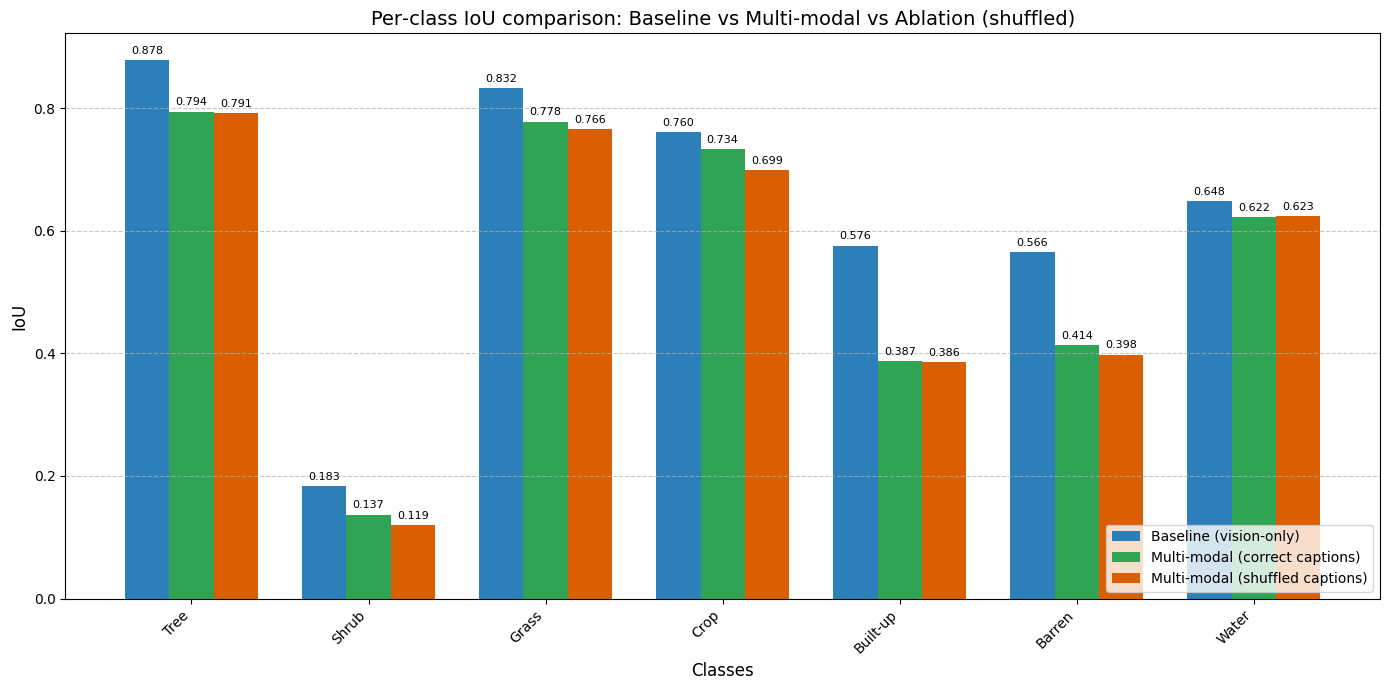

In [36]:
# Собираем данные для графика
categories = CLASS_NAMES
x = np.arange(len(categories))
width = 0.25

baseline_ious = [baseline_per_class[i] for i in range(NUM_CLASSES)]
correct_ious = [per_class_correct[i] for i in range(NUM_CLASSES)]
shuffled_ious = [per_class_shuffled[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width, baseline_ious, width, label='Baseline (vision‑only)', color='#2c7fb8')
rects2 = ax.bar(x, correct_ious, width, label='Multi‑modal (correct captions)', color='#31a354')
rects3 = ax.bar(x + width, shuffled_ious, width, label='Multi‑modal (shuffled captions)', color='#d95f02')

ax.set_ylabel('IoU', fontsize=12)
ax.set_xlabel('Classes', fontsize=12)
ax.set_title('Per‑class IoU comparison: Baseline vs Multi‑modal vs Ablation (shuffled)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig("per_class_iou_ablation.png", dpi=150)
plt.show()

In [37]:
wandb.log({
    "ablation/mIoU_correct": miou_correct,
    "ablation/mIoU_shuffled": miou_shuffled,
    "ablation/mIoU_baseline": baseline_miou,
    "ablation/drop_mIoU_due_to_shuffle": miou_correct - miou_shuffled,
})

for i, name in enumerate(CLASS_NAMES):
    wandb.log({
        f"per_class_iou/baseline_{name}": baseline_per_class[i],
        f"per_class_iou/correct_{name}": per_class_correct[i],
        f"per_class_iou/shuffled_{name}": per_class_shuffled[i],
    })

wandb.log({"per_class_iou_comparison": wandb.Image("per_class_iou_ablation.png")})

print("✅ All metrics logged to WandB.")
wandb.finish()

✅ All metrics logged to WandB.


ablation/drop_mIoU_due_to_shuffle,▁
ablation/mIoU_baseline,▁
ablation/mIoU_correct,▁
ablation/mIoU_shuffled,▁
per_class_iou/baseline_Barren,▁
per_class_iou/baseline_Built-up,▁
per_class_iou/baseline_Crop,▁
per_class_iou/baseline_Grass,▁
per_class_iou/baseline_Shrub,▁
per_class_iou/baseline_Tree,▁
+15,...
